# `from_sensorfilter` — auto-selecting the PSF from the filter focus level

The WCC ETC supports building a simulation directly from a **canonical sensorfilter label**
(`kind:band`, e.g. `'zwo:r'`) with `Simulation.from_sensorfilter` and
`ImageSimulator.from_sensorfilter`.

Unlike `from_sensor_and_scene`, these classmethods do two things automatically:

1. **Pick the throughput curve** for that sensor/filter combination.
2. **Pick the default PSF** from the filter's `focus_level`, storing it on `_default_psf`.

Focus levels map to PSFs as follows:

| `focus_level` | PSF | example label |
|---|---|---|
| `0wave` (in focus) | `AiryPSF` | `zwo:r`, `zwo:bb` |
| `1wave` (±1 wave defocus) | `DefocusPSF` (1 wave) | `zwo:r+1`, `zwo:r-1` |
| `2wave` (+2 wave defocus) | `DefocusPSF` (2 wave) | `zwo:bb2` |

Because the PSF is stored on the simulation, `get_image_snr(time=...)` uses the right PSF
**without any `psf=` argument**. Defocusing spreads the star over more pixels, so at a fixed
aperture the SNR drops relative to the in-focus case.

## Imports and scene setup

We use a single G5V source at r = 15 against a zodiacal background. The `import wcc_etc`
line emits a harmless deprecation warning, which we silence for a clean demo.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
wcc_etc.set_wcc_style()
from wcc_etc import AiryPSF, DefocusPSF

def make_scene(mag=15):
    """G5V source on a zodi background, johnson_r bandpass."""
    return wcc_etc.get_scene(name='G5V', mag=mag, background='zodi',
                             bandpass='johnson_r',
                             background_prop={'bandpass': 'johnson_r', 'mag': 22.5})

scene = make_scene(mag=15)
scene

## 1. In-focus filter (`zwo:r`) → `AiryPSF`

Build a `Simulation` from the canonical in-focus label `'zwo:r'`. Its `focus_level` is
`0wave`, so `from_sensorfilter` stores an `AiryPSF` as the default.

In [2]:
sim_infocus = wcc_etc.Simulation.from_sensorfilter('zwo:r', make_scene(15))

print('label        : zwo:r')
print('_default_psf :', type(sim_infocus._default_psf).__name__)
assert isinstance(sim_infocus._default_psf, AiryPSF)
print('is AiryPSF    :', isinstance(sim_infocus._default_psf, AiryPSF))

label        : zwo:r
_default_psf : AiryPSF
is AiryPSF    : True


## 2. Defocused filters (`zwo:r+1`, `zwo:bb2`) → `DefocusPSF`

The `+1` / `-1` / `2` suffixes on a label mark a defocused sensor. `from_sensorfilter`
auto-selects the matching `DefocusPSF` (1-wave or 2-wave).

In [3]:
builds = {
    'zwo:r':   wcc_etc.Simulation.from_sensorfilter('zwo:r',   make_scene(15)),
    'zwo:r+1': wcc_etc.Simulation.from_sensorfilter('zwo:r+1', make_scene(15)),
    'zwo:bb2': wcc_etc.Simulation.from_sensorfilter('zwo:bb2', make_scene(15)),
}

print(f"{'label':<10}{'focus':<8}{'_default_psf'}")
print('-' * 34)
labels_focus = {'zwo:r': '0wave', 'zwo:r+1': '1wave', 'zwo:bb2': '2wave'}
for label, sim in builds.items():
    print(f"{label:<10}{labels_focus[label]:<8}{type(sim._default_psf).__name__}")

assert isinstance(builds['zwo:r+1']._default_psf, DefocusPSF)
assert isinstance(builds['zwo:bb2']._default_psf, DefocusPSF)

label     focus   _default_psf
----------------------------------
zwo:r     0wave   AiryPSF
zwo:r+1   1wave   DefocusPSF
zwo:bb2   2wave   DefocusPSF


## 3. Visualizing the auto-selected PSFs

We render a bright (r = 11) point source through each build with
`ImageSimulator.from_sensorfilter`, passing the auto-selected `_default_psf` to `simulate`.
The in-focus image is a tight Airy core; the 1-wave and 2-wave defocus images spread the
light into progressively larger doughnuts.

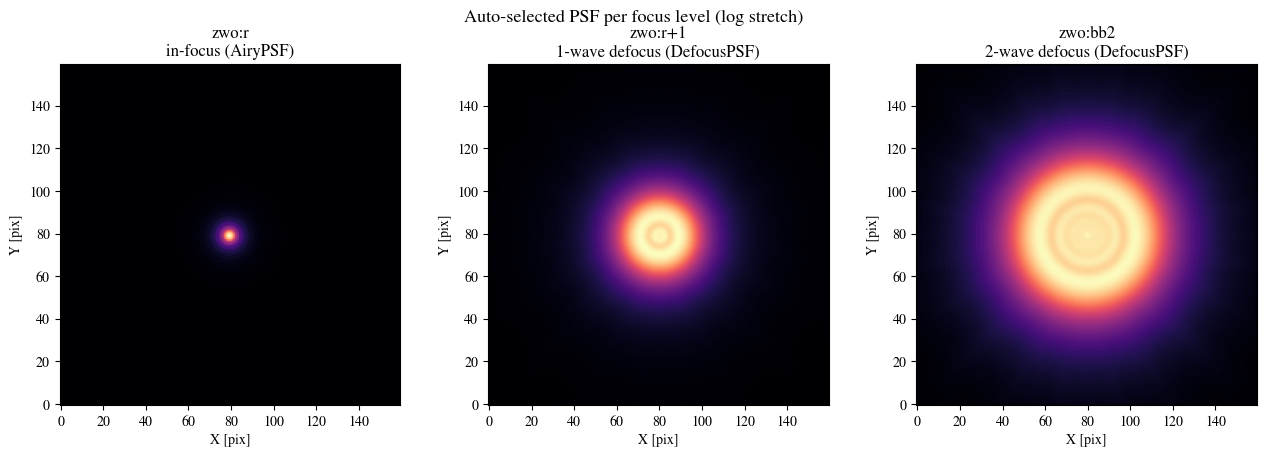

In [4]:
panels = [
    ('zwo:r',   'in-focus (AiryPSF)'),
    ('zwo:r+1', '1-wave defocus (DefocusPSF)'),
    ('zwo:bb2', '2-wave defocus (DefocusPSF)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (label, title) in zip(axes, panels):
    img = wcc_etc.ImageSimulator.from_sensorfilter(label, make_scene(11),
                                                   npix=160, oversample=5)
    sim_img = img.simulate(time=5, psf=img.sim._default_psf, add_noise=False)
    # SimulatedImage.plot_image draws straight into our axis (noiseless, log stretch)
    sim_img.plot_image(ax=ax, noise=False, stretch='log', cmap='magma',
                       colorbar=False, title=f'{label}\n{title}')

fig.suptitle('Auto-selected PSF per focus level (log stretch)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. `get_image_snr` uses `_default_psf` automatically

No `psf=` argument is needed: `get_image_snr(time=60)` picks up whatever PSF
`from_sensorfilter` stored. At a fixed aperture, spreading the flux out via defocus lowers
the SNR — `zwo:r` > `zwo:r+1` > `zwo:bb2`.

In [5]:
time = 60  # seconds

print(f"{'label':<10}{'PSF':<14}{'SNR (60 s, no psf= arg)'}")
print('-' * 46)
snr_results = {}
for label in ['zwo:r', 'zwo:r+1', 'zwo:bb2']:
    sim = wcc_etc.Simulation.from_sensorfilter(label, make_scene(15))
    snr = sim.get_image_snr(time=time)['snr']   # uses _default_psf automatically
    snr_results[label] = snr
    print(f"{label:<10}{type(sim._default_psf).__name__:<14}{snr:8.2f}")

print()
print(f"in-focus / 1-wave SNR ratio: {snr_results['zwo:r'] / snr_results['zwo:r+1']:.2f}x")
print(f"in-focus / 2-wave SNR ratio: {snr_results['zwo:r'] / snr_results['zwo:bb2']:.2f}x")
assert snr_results['zwo:r'] > snr_results['zwo:r+1'] > snr_results['zwo:bb2']

label     PSF           SNR (60 s, no psf= arg)
----------------------------------------------


zwo:r     AiryPSF        1380.40


zwo:r+1   DefocusPSF      401.13


zwo:bb2   DefocusPSF      311.82

in-focus / 1-wave SNR ratio: 3.44x
in-focus / 2-wave SNR ratio: 4.43x


## 5. Guards

`from_sensorfilter` only accepts **canonical** labels and only those with a throughput curve:

- An unknown label raises `ValueError`.
- A known-but-unimplemented label (a narrowband filter with no throughput curve yet, e.g.
  `zwo:halpha`) raises `NotImplementedError`.

Note nicknames like `'sony:r'` are not valid here — use `from_sensor_and_scene` for those.

In [6]:
try:
    wcc_etc.Simulation.from_sensorfilter('zwo:does_not_exist', make_scene(15))
except ValueError as e:
    print('ValueError       :', e)

try:
    wcc_etc.Simulation.from_sensorfilter('zwo:halpha', make_scene(15))
except NotImplementedError as e:
    print('NotImplementedError:', e)

ValueError       : Unknown sensorfilter 'zwo:does_not_exist'. Known labels: ['qcmos:bb', 'qcmos:g', 'qcmos:i', 'qcmos:u', 'qcmos:z', 'zwo:bb', 'zwo:bb2', 'zwo:g', 'zwo:halpha', 'zwo:hbeta', 'zwo:heii', 'zwo:i', 'zwo:nii', 'zwo:oiii', 'zwo:r', 'zwo:r+1', 'zwo:r-1', 'zwo:u', 'zwo:z']
NotImplementedError: Sensorfilter 'zwo:halpha' is not yet implemented (no throughput curve available).


## Summary

- `Simulation.from_sensorfilter(label, scene)` and
  `ImageSimulator.from_sensorfilter(label, scene, npix=..., oversample=...)` build from a
  canonical `kind:band` label.
- The PSF is chosen from the filter's `focus_level` and stored on `_default_psf`
  (`AiryPSF` for `0wave`; `DefocusPSF` for `1wave` / `2wave`).
- `get_image_snr` / `get_image_exptime_for_snr` use `_default_psf` automatically — no `psf=`
  needed — and defocus lowers SNR at fixed aperture.
- Unknown labels raise `ValueError`; known-but-unimplemented labels raise
  `NotImplementedError`. For nicknames (`'sony:r'`), use `from_sensor_and_scene`.